In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [3]:
# Adjust filename if needed
df = pd.read_csv(r"C:\Users\LENOVO\Documents\GitHub\ml-assessment-sumathi-srinivasan\data\q3_retail_promotions.csv")
df.head()


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [4]:
# 1. Date feature engineering

# Ensure transaction_date is datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract date features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek  # Monday=0, Sunday=6

# Binary month-end feature
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df[[
    "transaction_date",
    "year", "month", "day_of_week", "is_month_end"
]].head()


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


In [ ]:
# 2. Temporal train–test split

# Sort by date
df_sorted = df.sort_values("transaction_date").reset_index(drop=True)

n = len(df_sorted)
split_idx = int(n * 0.8)

train = df_sorted.iloc[:split_idx]
test = df_sorted.iloc[split_idx:]

len(train), len(test)


why not random split:

For time-ordered data, a random train–test split would mix past and future records, allowing the model to “see” future information during training. This leads to data leakage and overly optimistic performance estimates. A temporal split that uses earlier records for training and later records for testing better reflects the real-world scenario of predicting future outcomes from past data

In [ ]:
# 3. Preprocessing pipeline

# Sort by date
df_sorted = df.sort_values("transaction_date").reset_index(drop=True)

n = len(df_sorted)
split_idx = int(n * 0.8)

train = df_sorted.iloc[:split_idx]
test = df_sorted.iloc[split_idx:]


In [7]:
df_sorted.head()


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [ ]:

target_col = "items_sold"

categorical_features = ["promotion_type", "location_type", "store_size"]
# All other numeric features (including engineered date features)
numeric_features = [
    col for col in df_sorted.columns
    if col not in categorical_features + [target_col, "transaction_date"]
]

X_train = train.drop(columns=[target_col])
y_train = train[target_col]

X_test = test.drop(columns=[target_col])
y_test = test[target_col]


In [9]:
# Preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [12]:
# 4. Model training and evaluation

# 4.1 Linear Regression pipeline

linreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linreg_pipeline.fit(X_train, y_train)

y_pred_lr = linreg_pipeline.predict(X_test)

rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr, mae_lr


(27.12145116489063, 21.052926674588395)

In [13]:
# 4.2 Random Forest pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

# Random Forest metrics
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf, mae_rf



(30.72883030098391, 24.33083333333333)

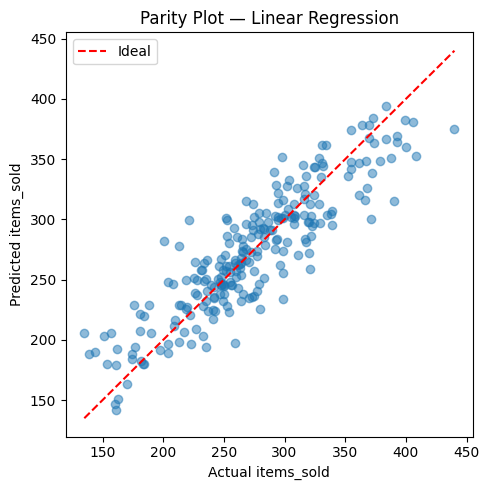

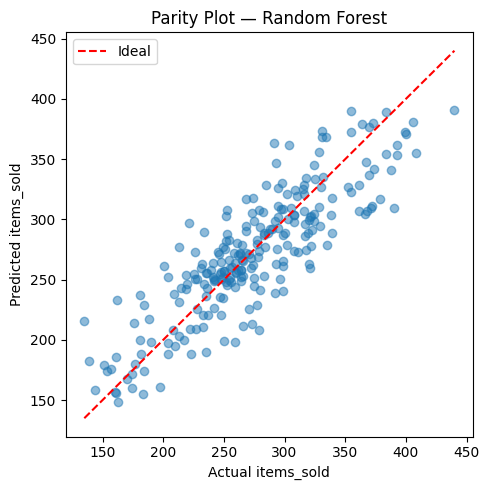

In [14]:
# 4.3 Parity plots (predicted vs actual)

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

parity_plot(y_test, y_pred_lr, "Parity Plot — Linear Regression")
parity_plot(y_test, y_pred_rf, "Parity Plot — Random Forest")


In [15]:
# 4.4 Random Forest feature importances

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(10)


,feature,importance
2,num__is_festival,0.176175
18,cat__store_size_small,0.162664
15,cat__location_type_urban,0.111594
6,num__day_of_week,0.085278
1,num__is_weekend,0.063324
0,num__store_id,0.053927
13,cat__location_type_rural,0.051607
16,cat__store_size_large,0.050466
3,num__competition_density,0.050118
5,num__month,0.037575


In [17]:
feat_imp.head(5)

,feature,importance
2,num__is_festival,0.176175
18,cat__store_size_small,0.162664
15,cat__location_type_urban,0.111594
6,num__day_of_week,0.085278
1,num__is_weekend,0.063324


Top 5 Most Influential Features — Interpretation
The Random Forest model identified the following features as the strongest predictors of items_sold:

num__is_festival — 0.176  
Festival days significantly increase store traffic and demand. This feature being the most important suggests that sales spike during festivals, making it a key driver of items sold.

cat__store_size_small — 0.163  
Smaller stores show distinct sales patterns compared to medium or large stores. This importance indicates that store size strongly influences sales capacity, product variety, and customer flow.

cat__location_type_urban — 0.112  
Urban stores tend to have higher footfall and more consistent demand. The model relies heavily on this feature, showing that location context plays a major role in predicting sales.

num__day_of_week — 0.085  
Sales vary across weekdays and weekends. This feature captures weekly seasonality—certain days (e.g., Fridays or weekends) may consistently show higher or lower sales.

num__is_weekend — 0.063  
Weekends typically bring increased shopping activity. This feature’s importance confirms that weekend effects meaningfully impact sales volume.